# AI-Powered Cybersecurity Machine Learning Pipeline
## Exploratory Data Analysis (EDA)

**Author:** Pramod Prakash Jadhav

**Python Version:** 3.11+

**Project:** End-to-End Applied AI & ML Data Product Capstone – Part 2

---

# Business Problem

Modern organizations generate thousands of cybersecurity events every day from firewalls, intrusion detection systems, endpoint security solutions, and network devices.

Raw cybersecurity data often contains:

- Missing values
- Duplicate records
- Invalid timestamps
- Inconsistent attack categories
- Incorrect severity labels
- Data quality issues

These problems reduce the reliability of analytics and machine learning models.

---

# Project Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cybersecurity incidents dataset before building machine learning models.

This notebook helps to:

- Understand the dataset
- Assess data quality
- Detect missing values
- Identify duplicate records
- Analyze numerical and categorical features
- Explore the target variable
- Detect outliers
- Study feature relationships
- Generate business insights

---

# Dataset Information

**Dataset Name**

Cyber Security Attacks Dataset

**Expected Location**

```
data/raw/cybersecurity_incidents.csv
```

---

# Machine Learning Workflow

```
Raw Dataset
      │
      ▼
Data Exploration
      │
      ▼
Data Cleaning
      │
      ▼
Feature Engineering
      │
      ▼
Feature Selection
      │
      ▼
Model Training
      │
      ▼
Model Evaluation
      │
      ▼
Prediction
```

---

# Expected Outputs

After executing this notebook, the following insights will be generated:

- Dataset Overview
- Data Quality Report
- Missing Value Analysis
- Duplicate Analysis
- Statistical Summary
- Target Variable Distribution
- Feature Distributions
- Correlation Analysis
- Outlier Detection
- Feature Importance Analysis
- Business Insights
- EDA Summary Report

---

# Notebook Execution

Run all cells sequentially from top to bottom.

The notebook is designed to execute successfully in:

- Google Colab
- Jupyter Notebook
- JupyterLab

---

**Let's begin the Exploratory Data Analysis.**

In [1]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 2 - Import Required Libraries
# ==========================================================

# Standard Library
import warnings
from pathlib import Path

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import LabelEncoder

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", None)

# Ignore Warnings
warnings.filterwarnings("ignore")

# Matplotlib Settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 60)
print("AI-Powered Cybersecurity ML Pipeline")
print("Exploratory Data Analysis Notebook")
print("=" * 60)
print("Libraries imported successfully.")

AI-Powered Cybersecurity ML Pipeline
Exploratory Data Analysis Notebook
Libraries imported successfully.


In [2]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 3 - Configure Project Paths
# ==========================================================

from pathlib import Path

# Project Root
PROJECT_ROOT = Path.cwd()

# Directory Structure
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Dataset File
DATASET_PATH = RAW_DATA_DIR / "cybersecurity_incidents.csv"

print("=" * 60)
print("Project Directories")
print("=" * 60)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Raw Data Folder   : {RAW_DATA_DIR}")
print(f"Processed Folder  : {PROCESSED_DATA_DIR}")
print(f"Output Folder     : {OUTPUT_DIR}")

print("\n" + "=" * 60)

# Verify Dataset
if DATASET_PATH.exists():
    print("Dataset Found")
    print(f"Location : {DATASET_PATH}")
else:
    print("Dataset NOT Found")
    print("Expected Location:")
    print(DATASET_PATH)

print("=" * 60)

Project Directories
Project Root      : /content
Raw Data Folder   : /content/data/raw
Processed Folder  : /content/data/processed
Output Folder     : /content/outputs

Dataset NOT Found
Expected Location:
/content/data/raw/cybersecurity_incidents.csv


In [6]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 4 - Load Dataset
# ==========================================================

print("=" * 60)
print("Loading Cybersecurity Dataset")
print("=" * 60)

try:
    # Load CSV
    df = pd.read_csv("/content/cybersecurity_incident_reports.csv")

    print("Dataset loaded successfully.\n")

    print(f"Number of Rows    : {df.shape[0]:,}")
    print(f"Number of Columns : {df.shape[1]}")

    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"Memory Usage      : {memory_mb:.2f} MB")

except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATASET_PATH}\n\n"
        "Place 'cybersecurity_incidents.csv' inside "
        "'data/raw/' and run the notebook again."
    )

except pd.errors.EmptyDataError:
    raise ValueError(
        "The dataset file exists but is empty."
    )

except Exception as error:
    raise RuntimeError(
        f"Failed to load dataset: {error}"
    )

print("\n" + "=" * 60)
print("First Five Records")
print("=" * 60)

display(df.head())

print("\nDataset loaded and ready for EDA.")

Loading Cybersecurity Dataset
Dataset loaded successfully.

Number of Rows    : 1,600
Number of Columns : 16
Memory Usage      : 0.67 MB

First Five Records


,incident_id,incident_date,sector,region,attack_type,threat_actor,records_affected,downtime_hours,ransom_demand_usd,detection_time_hours,severity_score,response_team_size,regulatory_fine_usd,resolved_within_7_days,data_exfiltration,zero_day_used
0,INC-00001,2024-12-29,Energy,Middle East & Africa,Phishing,State-Sponsored,100991,26.50,1393,26.48,6.24,4,0,1,0,0
1,INC-00002,2023-11-25,Retail,Latin America,Malware,Insider,136440,53.43,27667,35.26,5.89,16,0,1,0,0
2,INC-00003,2022-03-14,Government,Asia Pacific,Malware,Cybercriminal Group,47547,17.48,13588,50.70,5.86,7,49245,0,0,0
3,INC-00004,2024-08-29,Retail,Asia Pacific,Credential Theft,State-Sponsored,20357,56.63,28591,19.93,5.77,10,0,0,0,0
4,INC-00005,2023-04-07,Healthcare,Latin America,DDoS,Hacktivist,43241,8.84,5952,47.71,4.26,8,19890,0,0,0



Dataset loaded and ready for EDA.


In [7]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 5 - Dataset Structure & Information
# ==========================================================

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

# Dataset Shape
rows, cols = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df.dtypes.to_frame(name="Data Type"))

print("\n" + "=" * 60)
print("DATAFRAME INFORMATION")
print("=" * 60)

df.info()

print("\n" + "=" * 60)
print("MISSING VALUES (PREVIEW)")
print("=" * 60)

missing_preview = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (
        df.isnull().mean() * 100
    ).round(2)
})

display(missing_preview)

print("\nDataset structure analysis completed successfully.")

DATASET STRUCTURE
Rows    : 1,600
Columns : 16

COLUMN NAMES
01. incident_id
02. incident_date
03. sector
04. region
05. attack_type
06. threat_actor
07. records_affected
08. downtime_hours
09. ransom_demand_usd
10. detection_time_hours
11. severity_score
12. response_team_size
13. regulatory_fine_usd
14. resolved_within_7_days
15. data_exfiltration
16. zero_day_used

DATA TYPES


,Data Type
incident_id,object
incident_date,object
sector,object
region,object
attack_type,object
threat_actor,object
records_affected,int64
downtime_hours,float64
ransom_demand_usd,int64
detection_time_hours,float64



DATAFRAME INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             1600 non-null   object 
 1   incident_date           1600 non-null   object 
 2   sector                  1600 non-null   object 
 3   region                  1600 non-null   object 
 4   attack_type             1600 non-null   object 
 5   threat_actor            1600 non-null   object 
 6   records_affected        1600 non-null   int64  
 7   downtime_hours          1600 non-null   float64
 8   ransom_demand_usd       1600 non-null   int64  
 9   detection_time_hours    1600 non-null   float64
 10  severity_score          1600 non-null   float64
 11  response_team_size      1600 non-null   int64  
 12  regulatory_fine_usd     1600 non-null   int64  
 13  resolved_within_7_days  1600 non-null   int64  
 14  data_exfiltration

,Missing Values,Missing (%)
incident_id,0,0.0
incident_date,0,0.0
sector,0,0.0
region,0,0.0
attack_type,0,0.0
threat_actor,0,0.0
records_affected,0,0.0
downtime_hours,0,0.0
ransom_demand_usd,0,0.0
detection_time_hours,0,0.0



Dataset structure analysis completed successfully.


In [8]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 6 - Descriptive Statistics
# ==========================================================

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# Separate Numerical and Categorical Columns
numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

# ----------------------------------------------------------
# Numerical Statistics
# ----------------------------------------------------------

if numerical_columns:

    print("\n" + "=" * 60)
    print("NUMERICAL FEATURES SUMMARY")
    print("=" * 60)

    numerical_summary = (
        df[numerical_columns]
        .describe()
        .T
        .round(2)
    )

    display(numerical_summary)

else:

    print("\nNo numerical features found.")

# ----------------------------------------------------------
# Categorical Statistics
# ----------------------------------------------------------

if categorical_columns:

    print("\n" + "=" * 60)
    print("CATEGORICAL FEATURES SUMMARY")
    print("=" * 60)

    categorical_summary = (
        df[categorical_columns]
        .describe()
        .T
    )

    display(categorical_summary)

else:

    print("\nNo categorical features found.")

# ----------------------------------------------------------
# Missing Values Summary
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing (%)": (
        df.isna().mean() * 100
    ).round(2)
})

display(
    missing_summary.sort_values(
        by="Missing Values",
        ascending=False
    )
)

print("\nDescriptive statistics completed successfully.")

DESCRIPTIVE STATISTICS
Numerical Features   : 10
Categorical Features : 6

NUMERICAL FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
records_affected,1600.0,120778.66,136369.00,2700.00,37540.00,74769.50,150317.25,1143724.00
downtime_hours,1600.0,26.91,16.74,0.50,13.88,26.38,38.12,86.70
ransom_demand_usd,1600.0,60506.59,76497.87,0.00,3774.00,40604.50,80057.75,540616.00
detection_time_hours,1600.0,36.07,20.61,1.00,21.30,35.80,49.84,99.54
severity_score,1600.0,6.14,1.71,1.25,4.93,6.14,7.35,10.00
response_team_size,1600.0,10.44,3.89,2.00,8.00,10.00,13.00,23.00
regulatory_fine_usd,1600.0,30133.94,46961.00,0.00,0.00,15205.50,38985.00,328172.00
resolved_within_7_days,1600.0,0.46,0.50,0.00,0.00,0.00,1.00,1.00
data_exfiltration,1600.0,0.46,0.50,0.00,0.00,0.00,1.00,1.00
zero_day_used,1600.0,0.10,0.31,0.00,0.00,0.00,0.00,1.00



CATEGORICAL FEATURES SUMMARY


,count,unique,top,freq
incident_id,1600,1600,INC-01584,1
incident_date,1600,999,2023-01-27,6
sector,1600,8,Retail,228
region,1600,5,Latin America,342
attack_type,1600,7,DDoS,253
threat_actor,1600,5,Cybercriminal Group,358



MISSING VALUE SUMMARY


,Missing Values,Missing (%)
incident_id,0,0.0
incident_date,0,0.0
sector,0,0.0
region,0,0.0
attack_type,0,0.0
threat_actor,0,0.0
records_affected,0,0.0
downtime_hours,0,0.0
ransom_demand_usd,0,0.0
detection_time_hours,0,0.0



Descriptive statistics completed successfully.


# Missing Value Analysis

## Why Missing Values Matter

Missing values are one of the most common data quality issues in real-world cybersecurity datasets.

Incomplete records can:

- Reduce model accuracy
- Introduce bias into machine learning models
- Affect statistical analysis
- Produce misleading business insights
- Increase data preprocessing complexity

---

## Objectives

In this section, we will:

- Identify missing values in each feature
- Calculate the percentage of missing values
- Rank features by missing value percentage
- Determine whether imputation or data removal is required

---

## Business Impact

Accurate handling of missing values helps ensure that:

- Security incident reports remain reliable
- Machine learning models receive high-quality input
- Business decisions are based on complete and trustworthy data
- Predictive models achieve better performance

---

## Expected Outcome

By the end of this section, we will clearly understand:

- Which columns contain missing values
- The severity of missing data
- The preprocessing strategy required before model training

In [9]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 8 - Missing Value Analysis & Visualization
# ==========================================================

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

# Calculate missing values
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

# Sort by missing values
missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
).reset_index(drop=True)

display(missing_df)

# ----------------------------------------------------------
# Columns with Missing Values
# ----------------------------------------------------------

missing_columns = missing_df[
    missing_df["Missing Values"] > 0
]

print("\n" + "=" * 60)
print(f"Columns with Missing Values : {len(missing_columns)}")
print("=" * 60)

if missing_columns.empty:

    print("No missing values found in the dataset.")

else:

    display(missing_columns)

    # ------------------------------------------------------
    # Visualization
    # ------------------------------------------------------

    plt.figure(figsize=(12, 6))

    plt.bar(
        missing_columns["Column"],
        missing_columns["Missing Values"]
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Features")
    plt.ylabel("Missing Values")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# Data Quality Summary
# ----------------------------------------------------------

total_missing = df.isnull().sum().sum()

missing_percentage = (
    total_missing /
    (df.shape[0] * df.shape[1])
) * 100

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print(f"Total Missing Values : {total_missing:,}")
print(f"Missing Percentage   : {missing_percentage:.2f}%")

if total_missing == 0:
    print("Dataset Quality : Excellent")
elif missing_percentage < 5:
    print("Dataset Quality : Good")
elif missing_percentage < 20:
    print("Dataset Quality : Moderate")
else:
    print("Dataset Quality : Poor")

print("\nMissing value analysis completed successfully.")

MISSING VALUE ANALYSIS


,Column,Missing Values,Missing (%)
0,incident_id,0,0.0
1,incident_date,0,0.0
2,sector,0,0.0
3,region,0,0.0
4,attack_type,0,0.0
5,threat_actor,0,0.0
6,records_affected,0,0.0
7,downtime_hours,0,0.0
8,ransom_demand_usd,0,0.0
9,detection_time_hours,0,0.0



Columns with Missing Values : 0
No missing values found in the dataset.

DATA QUALITY SUMMARY
Total Missing Values : 0
Missing Percentage   : 0.00%
Dataset Quality : Excellent

Missing value analysis completed successfully.


# Duplicate Records Analysis

## Why Duplicate Records Matter

Duplicate records are a common data quality issue in cybersecurity datasets. They can occur due to repeated log collection, multiple monitoring systems reporting the same event, synchronization errors, or data ingestion issues.

If duplicate incidents are not identified and handled properly, they can negatively affect analytics and machine learning models.

---

## Objectives

In this section, we will:

- Detect duplicate records in the dataset
- Measure the number and percentage of duplicate entries
- Evaluate the impact of duplicates on data quality
- Determine whether duplicate records should be removed before model training

---

## Business Impact

Removing duplicate records helps to:

- Improve data quality and consistency
- Prevent over-counting of security incidents
- Produce more accurate dashboards and reports
- Reduce bias during machine learning model training
- Improve the reliability of business insights

---

## Expected Outcome

After completing this analysis, we will know:

- Total duplicate records in the dataset
- Percentage of duplicate records
- Overall impact on data quality
- Recommended preprocessing strategy before feature engineering and model training

---

> **Note:** Duplicate removal should be performed only after verifying that the records are truly identical and do not represent separate legitimate security events.

DUPLICATE RECORDS ANALYSIS
Total Records      : 1,600
Duplicate Records  : 0
Duplicate (%)      : 0.00%

No duplicate records found.


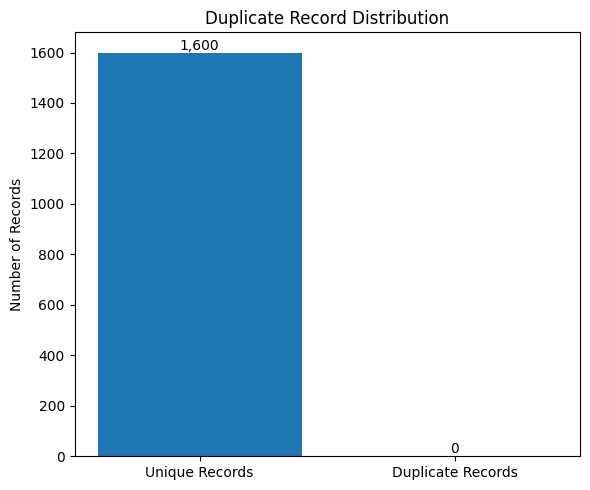


DUPLICATE DATA QUALITY ASSESSMENT
Dataset Quality : Excellent
Recommendation  : No duplicate removal is required.

Duplicate record analysis completed successfully.


In [10]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 10 - Duplicate Records Analysis
# ==========================================================

print("=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 60)

# ----------------------------------------------------------
# Detect Duplicate Records
# ----------------------------------------------------------

duplicate_mask = df.duplicated()

duplicate_count = duplicate_mask.sum()

duplicate_percentage = (
    duplicate_count / len(df) * 100
).round(2)

print(f"Total Records      : {len(df):,}")
print(f"Duplicate Records  : {duplicate_count:,}")
print(f"Duplicate (%)      : {duplicate_percentage:.2f}%")

# ----------------------------------------------------------
# Duplicate Preview
# ----------------------------------------------------------

if duplicate_count > 0:

    print("\n" + "=" * 60)
    print("SAMPLE DUPLICATE RECORDS")
    print("=" * 60)

    display(
        df[duplicate_mask]
        .head(10)
    )

else:

    print("\nNo duplicate records found.")

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(6, 5))

labels = [
    "Unique Records",
    "Duplicate Records"
]

values = [
    len(df) - duplicate_count,
    duplicate_count
]

plt.bar(labels, values)

plt.title("Duplicate Record Distribution")
plt.ylabel("Number of Records")

for index, value in enumerate(values):
    plt.text(
        index,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Data Quality Assessment
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE DATA QUALITY ASSESSMENT")
print("=" * 60)

if duplicate_count == 0:

    quality = "Excellent"
    recommendation = (
        "No duplicate removal is required."
    )

elif duplicate_percentage < 2:

    quality = "Good"
    recommendation = (
        "Remove duplicate records before model training."
    )

elif duplicate_percentage < 10:

    quality = "Moderate"
    recommendation = (
        "Duplicate removal is strongly recommended."
    )

else:

    quality = "Poor"
    recommendation = (
        "Investigate the data ingestion process before proceeding."
    )

print(f"Dataset Quality : {quality}")
print(f"Recommendation  : {recommendation}")

print("\nDuplicate record analysis completed successfully.")

# Target Variable Analysis

## Why Analyze the Target Variable?

The target variable is the outcome that the machine learning model will learn to predict.

Understanding the target variable is essential before model training because it directly influences:

- Model selection
- Performance evaluation
- Feature importance
- Prediction quality

---

## Target Variable

For this project, the target variable is:

**Severity**

Typical severity levels include:

- Low
- Medium
- High
- Critical

The objective of the machine learning model is to predict the severity level of a cybersecurity incident based on the available incident attributes.

---

## Objectives

In this section, we will:

- Identify the target variable
- Analyze the distribution of each severity class
- Detect class imbalance
- Calculate the percentage of each class
- Understand how the target distribution may affect model performance

---

## Business Impact

Analyzing the target variable helps security teams to:

- Understand the frequency of different incident severities
- Prioritize response efforts for critical incidents
- Allocate security resources more effectively
- Improve automated incident triage
- Build more reliable predictive models

---

## Expected Outcome

After completing this analysis, we will know:

- The number of incidents in each severity category
- Whether the dataset is balanced or imbalanced
- If additional preprocessing techniques (such as class balancing) may be required before training machine learning models

---

> **Note:** An imbalanced target variable may lead to biased predictions. If one severity class dominates the dataset, techniques such as class weighting, oversampling, or undersampling may be considered during model training.

TARGET VARIABLE ANALYSIS

Target Variable Summary



,Count,Percentage (%)
severity_score,,
1.25,1,0.06
1.53,1,0.06
1.64,1,0.06
1.65,1,0.06
1.81,1,0.06
...,...,...
9.90,1,0.06
9.91,1,0.06
9.95,1,0.06


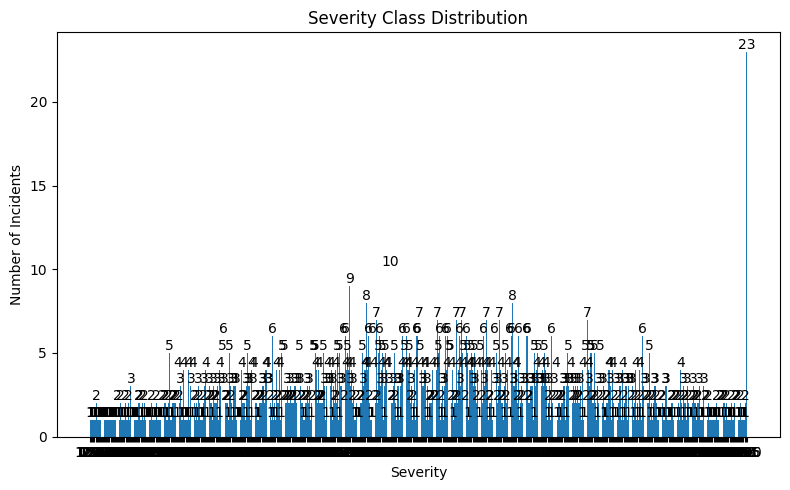

CLASS BALANCE ASSESSMENT
Largest Class : 23
Smallest Class: 1
Imbalance Ratio: 23.0:1
Dataset Status : Highly Imbalanced

Target variable analysis completed successfully.


In [13]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 12 - Target Variable Distribution
# ==========================================================

print("=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

TARGET_COLUMN = "severity_score"

# ----------------------------------------------------------
# Validate Target Column
# ----------------------------------------------------------

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found in the dataset."
    )

# ----------------------------------------------------------
# Target Distribution
# ----------------------------------------------------------

target_counts = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .sort_index()
)

target_percentage = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .sort_index()
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentage
})

print("\nTarget Variable Summary\n")
display(target_summary)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    target_summary.index.astype(str),
    target_summary["Count"]
)

plt.title("Severity Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Incidents")

for index, value in enumerate(target_summary["Count"]):
    plt.text(
        index,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Class Imbalance Analysis
# ----------------------------------------------------------

largest_class = target_counts.max()
smallest_class = target_counts.min()

imbalance_ratio = round(
    largest_class / smallest_class,
    2
)

print("=" * 60)
print("CLASS BALANCE ASSESSMENT")
print("=" * 60)

print(f"Largest Class : {largest_class}")
print(f"Smallest Class: {smallest_class}")
print(f"Imbalance Ratio: {imbalance_ratio}:1")

if imbalance_ratio <= 1.5:
    status = "Balanced"

elif imbalance_ratio <= 3:
    status = "Moderately Imbalanced"

else:
    status = "Highly Imbalanced"

print(f"Dataset Status : {status}")

print("\nTarget variable analysis completed successfully.")

# Numerical Feature Analysis

## Why Analyze Numerical Features?

Numerical features contain measurable values that help us understand the statistical characteristics of cybersecurity incidents.

Examples include:

- Network traffic volume
- Packet size
- Connection duration
- Number of failed login attempts
- Alert count
- Bytes transferred

These features often provide valuable signals for detecting suspicious activities and predicting incident severity.

---

## Objectives

In this section, we will:

- Identify all numerical features
- Examine the distribution of each feature
- Detect skewed distributions
- Identify unusual values
- Understand the overall range and spread of the data

---

## Business Impact

Analyzing numerical features helps security analysts to:

- Understand normal system behavior
- Detect abnormal activity patterns
- Identify unusually large or small values
- Improve feature engineering
- Build more accurate machine learning models

---

## Visualization Strategy

The following plots will be generated for each numerical feature:

- Histogram
- Distribution analysis
- Basic descriptive statistics
- Outlier identification (next section)

These visualizations help identify whether transformations such as normalization, scaling, or logarithmic conversion may be required before model training.

---

## Expected Outcome

By the end of this section, we will understand:

- The distribution of each numerical feature
- The range and variability of values
- Potential skewness
- Features requiring additional preprocessing before machine learning

NUMERICAL FEATURE DISTRIBUTIONS
Total Numerical Features: 10

Numerical Features:
• records_affected
• downtime_hours
• ransom_demand_usd
• detection_time_hours
• severity_score
• response_team_size
• regulatory_fine_usd
• resolved_within_7_days
• data_exfiltration
• zero_day_used


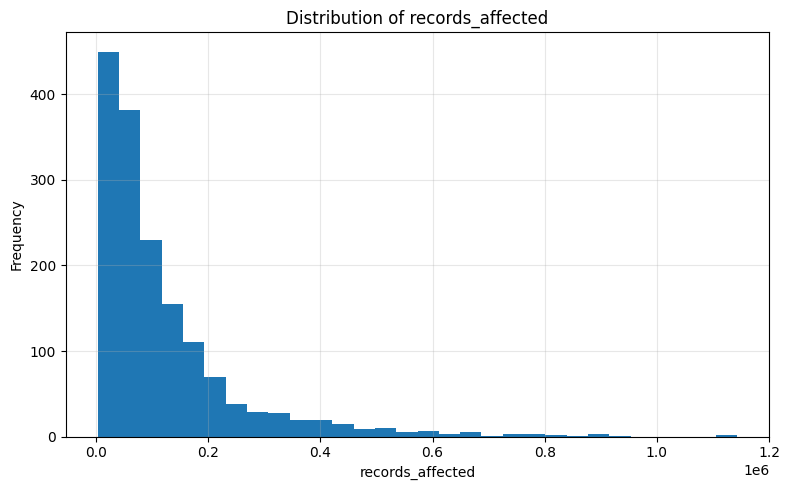


Summary Statistics for 'records_affected'


,records_affected
count,1.600000e+03
mean,1.207787e+05
std,1.363690e+05
min,2.700000e+03
25%,3.754000e+04
50%,7.476950e+04
75%,1.503172e+05
max,1.143724e+06


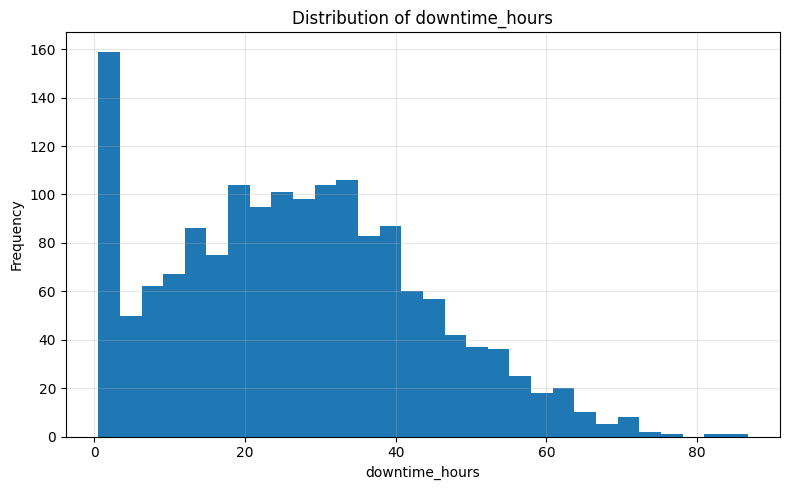


Summary Statistics for 'downtime_hours'


,downtime_hours
count,1600.000000
mean,26.907988
std,16.739827
min,0.500000
25%,13.885000
50%,26.375000
75%,38.117500
max,86.700000


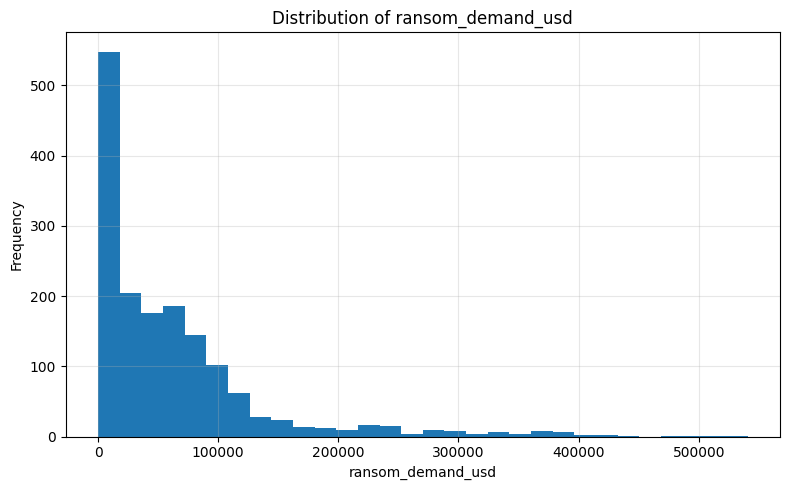


Summary Statistics for 'ransom_demand_usd'


,ransom_demand_usd
count,1600.000000
mean,60506.586250
std,76497.870132
min,0.000000
25%,3774.000000
50%,40604.500000
75%,80057.750000
max,540616.000000


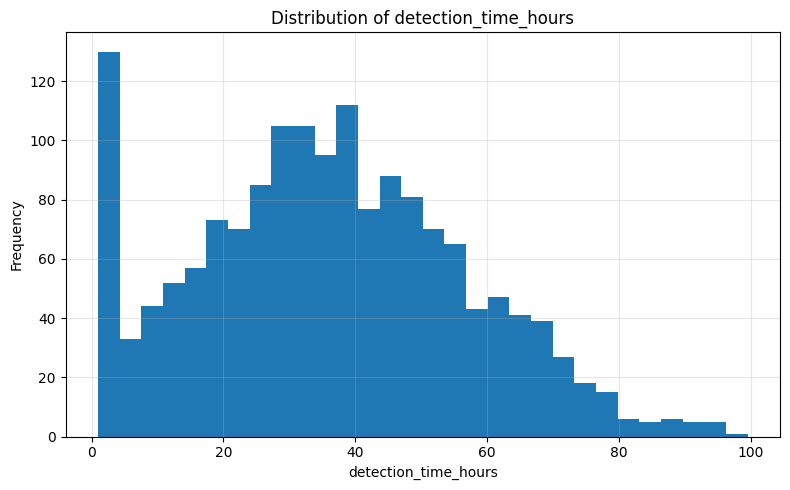


Summary Statistics for 'detection_time_hours'


,detection_time_hours
count,1600.000000
mean,36.070356
std,20.605622
min,1.000000
25%,21.295000
50%,35.795000
75%,49.845000
max,99.540000


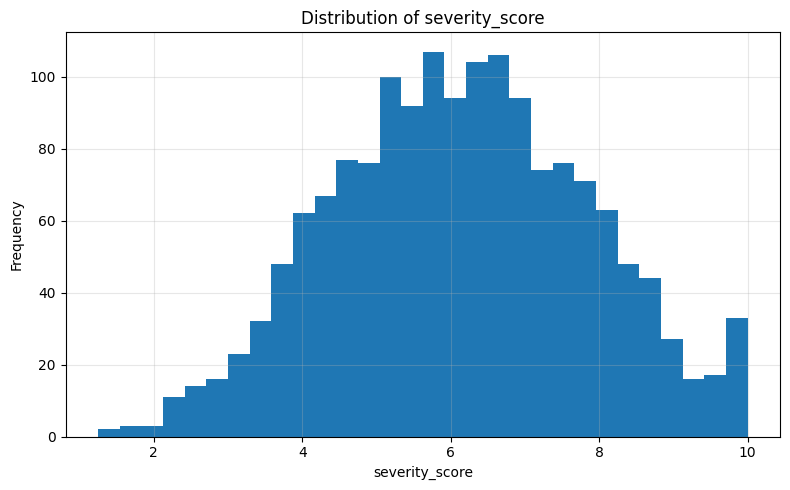


Summary Statistics for 'severity_score'


,severity_score
count,1600.000000
mean,6.135131
std,1.712054
min,1.250000
25%,4.930000
50%,6.135000
75%,7.352500
max,10.000000


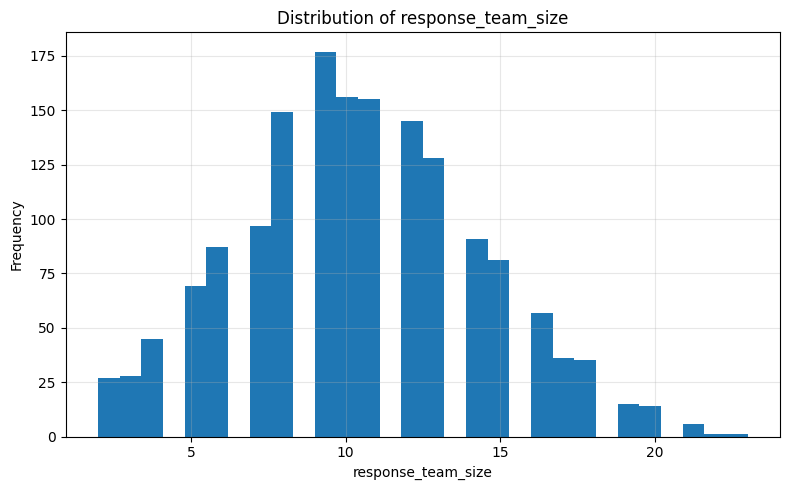


Summary Statistics for 'response_team_size'


,response_team_size
count,1600.000000
mean,10.435625
std,3.894912
min,2.000000
25%,8.000000
50%,10.000000
75%,13.000000
max,23.000000


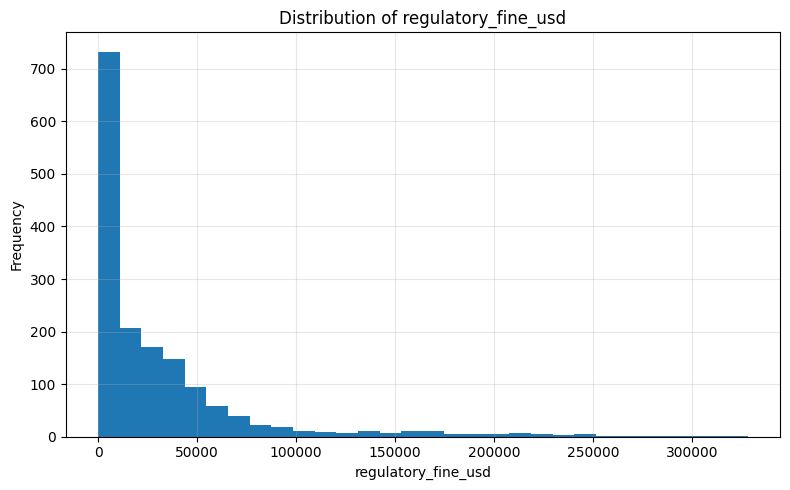


Summary Statistics for 'regulatory_fine_usd'


,regulatory_fine_usd
count,1600.000000
mean,30133.935000
std,46960.995049
min,0.000000
25%,0.000000
50%,15205.500000
75%,38985.000000
max,328172.000000


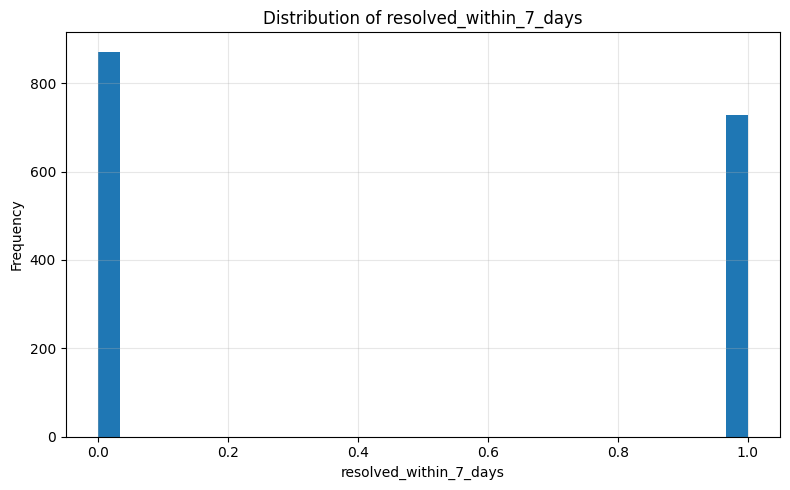


Summary Statistics for 'resolved_within_7_days'


,resolved_within_7_days
count,1600.000000
mean,0.455000
std,0.498127
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


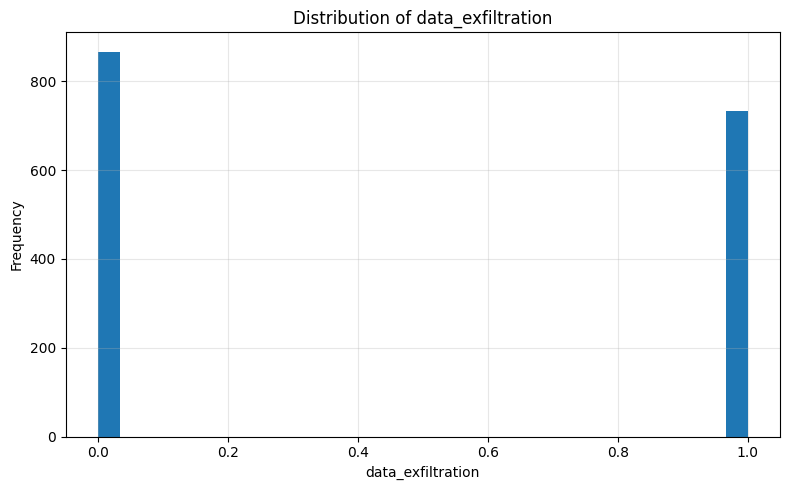


Summary Statistics for 'data_exfiltration'


,data_exfiltration
count,1600.000000
mean,0.458125
std,0.498399
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


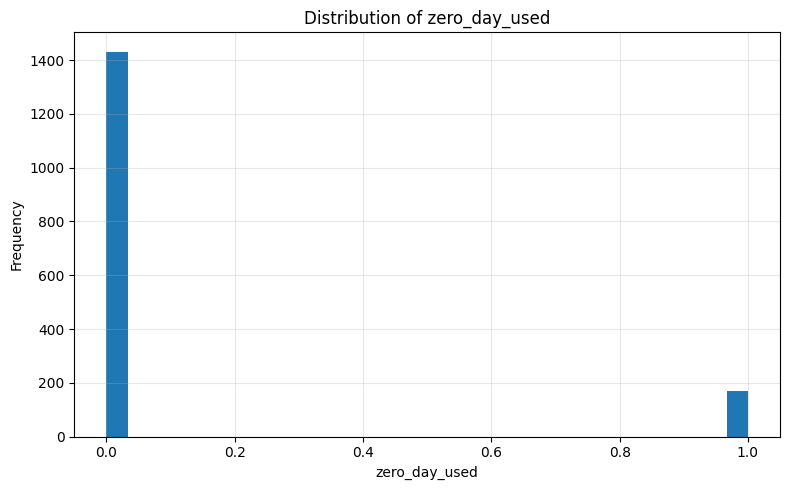


Summary Statistics for 'zero_day_used'


,zero_day_used
count,1600.000000
mean,0.105000
std,0.306649
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000



Numerical feature distribution analysis completed.


In [14]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 14 - Numerical Feature Distributions
# ==========================================================

print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

# ----------------------------------------------------------
# Identify Numerical Features
# ----------------------------------------------------------

numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Total Numerical Features: {len(numerical_columns)}")

if len(numerical_columns) == 0:

    print("\nNo numerical features found in the dataset.")

else:

    print("\nNumerical Features:")

    for column in numerical_columns:
        print(f"• {column}")

    # ------------------------------------------------------
    # Histogram for each Numerical Feature
    # ------------------------------------------------------

    for column in numerical_columns:

        plt.figure(figsize=(8, 5))

        plt.hist(
            df[column].dropna(),
            bins=30
        )

        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")

        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"\nSummary Statistics for '{column}'")

        display(
            df[column]
            .describe()
            .to_frame(name=column)
        )

print("\n" + "=" * 60)
print("Numerical feature distribution analysis completed.")
print("=" * 60)

OUTLIER DETECTION


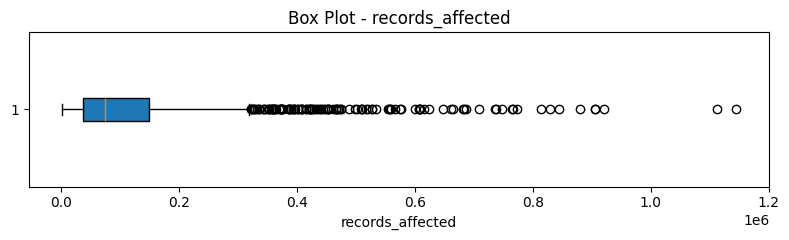

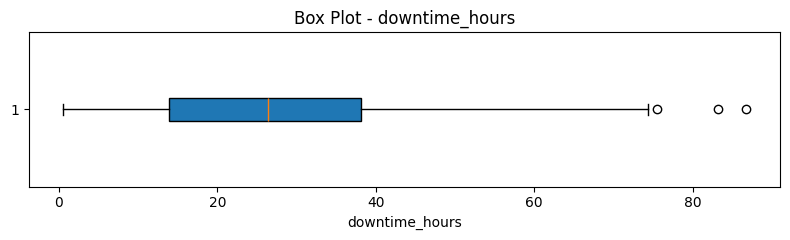

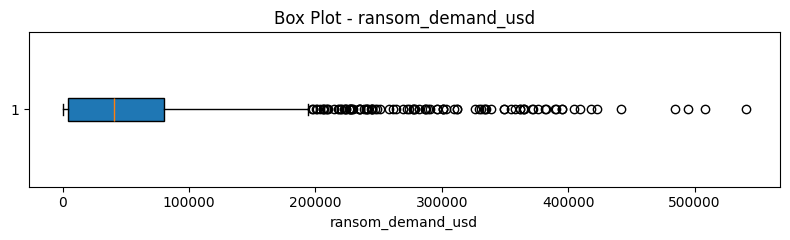

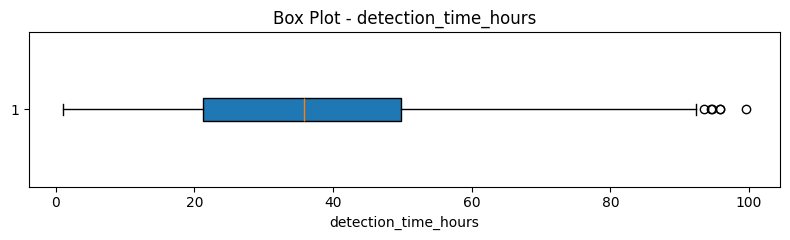

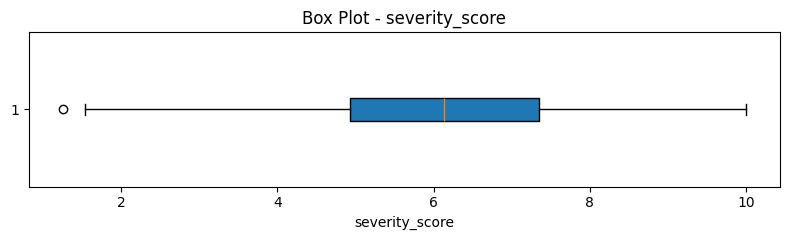

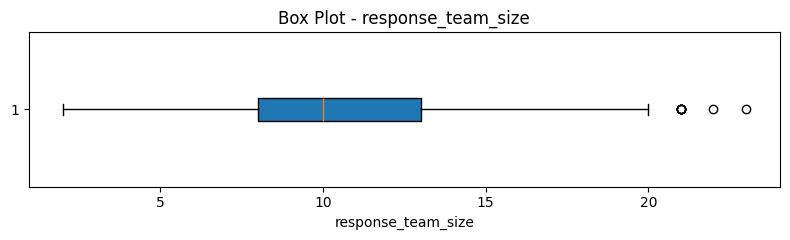

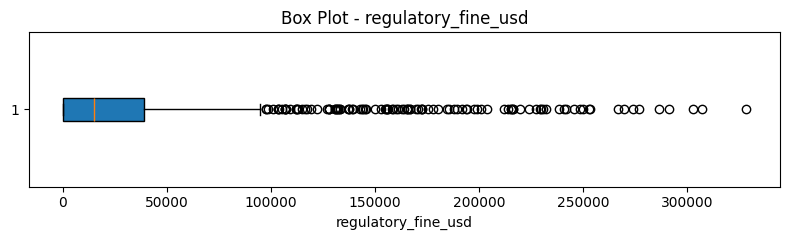

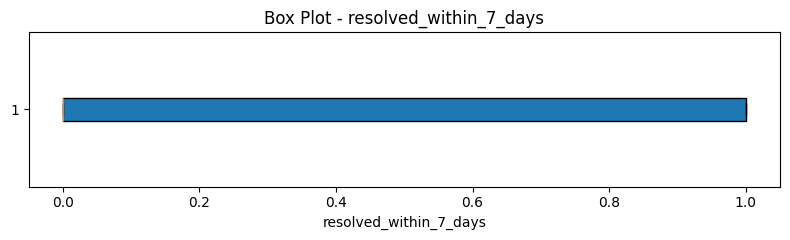

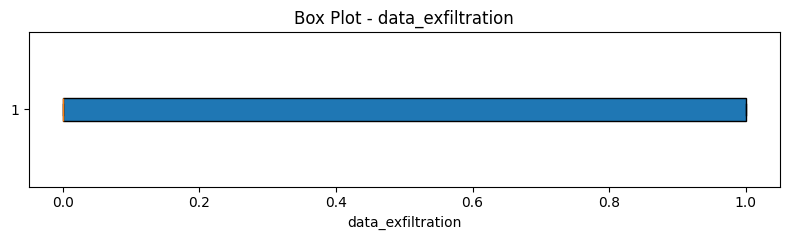

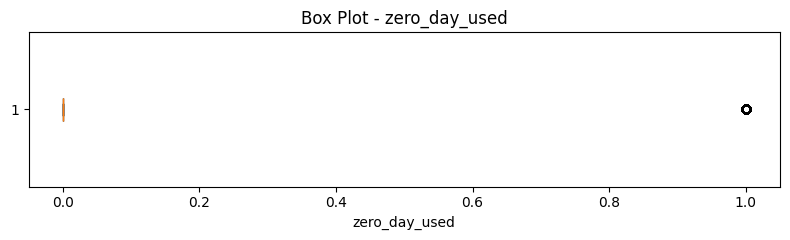


Outlier Summary


,Feature,Outliers,Outlier (%)
9,zero_day_used,168,10.50
0,records_affected,119,7.44
6,regulatory_fine_usd,111,6.94
2,ransom_demand_usd,102,6.38
5,response_team_size,8,0.50
3,detection_time_hours,6,0.38
1,downtime_hours,3,0.19
4,severity_score,1,0.06
7,resolved_within_7_days,0,0.00
8,data_exfiltration,0,0.00



Outlier analysis completed successfully.


In [15]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 15 - Outlier Detection using Box Plots
# ==========================================================

print("=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

# ----------------------------------------------------------
# Select Numerical Features
# ----------------------------------------------------------

numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

if not numerical_columns:

    print("No numerical features available for outlier analysis.")

else:

    outlier_summary = []

    for column in numerical_columns:

        data = df[column].dropna()

        if data.empty:
            continue

        # --------------------------------------------------
        # IQR Calculation
        # --------------------------------------------------

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outliers = data[
            (data < lower_bound) |
            (data > upper_bound)
        ]

        outlier_summary.append({
            "Feature": column,
            "Outliers": len(outliers),
            "Outlier (%)": round(
                (len(outliers) / len(data)) * 100,
                2
            )
        })

        # --------------------------------------------------
        # Box Plot
        # --------------------------------------------------

        plt.figure(figsize=(8, 2.5))

        plt.boxplot(
            data,
            vert=False,
            patch_artist=True
        )

        plt.title(f"Box Plot - {column}")
        plt.xlabel(column)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------
    # Outlier Summary Table
    # ------------------------------------------------------

    outlier_summary_df = pd.DataFrame(
        outlier_summary
    ).sort_values(
        by="Outliers",
        ascending=False
    )

    print("\nOutlier Summary")

    display(outlier_summary_df)

print("\n" + "=" * 60)
print("Outlier analysis completed successfully.")
print("=" * 60)

# Correlation Analysis

## Why Correlation Analysis?

Correlation analysis helps us understand the relationship between numerical features in the cybersecurity dataset.

Highly correlated features may contain similar information, while weakly correlated features often provide unique insights. Understanding these relationships improves feature engineering and model performance.

---

## Objectives

In this section, we will:

- Compute the correlation matrix for all numerical features
- Identify strong positive and negative relationships
- Detect multicollinearity among features
- Understand feature dependencies before model training

---

## Business Impact

Correlation analysis enables security teams to:

- Identify features that move together
- Detect redundant variables
- Improve feature selection
- Build simpler and more efficient machine learning models
- Enhance model interpretability

---

## Interpretation Guide

Correlation coefficients range from **-1 to +1**.

| Correlation Value | Interpretation |
|------------------:|----------------|
| +1.00 | Perfect Positive Correlation |
| +0.70 to +0.99 | Strong Positive Correlation |
| +0.30 to +0.69 | Moderate Positive Correlation |
| -0.29 to +0.29 | Weak or No Correlation |
| -0.30 to -0.69 | Moderate Negative Correlation |
| -0.70 to -0.99 | Strong Negative Correlation |
| -1.00 | Perfect Negative Correlation |

---

## Expected Outcome

By the end of this section, we will:

- Understand relationships among numerical features
- Identify highly correlated feature pairs
- Detect potential multicollinearity
- Support better feature engineering and feature selection decisions

---

> **Note:** Correlation indicates statistical association between variables. It should not be interpreted as proof of a cause-and-effect relationship.

CORRELATION ANALYSIS

Correlation Matrix



,records_affected,downtime_hours,ransom_demand_usd,detection_time_hours,severity_score,response_team_size,regulatory_fine_usd,resolved_within_7_days,data_exfiltration,zero_day_used
records_affected,1.00,-0.01,0.01,-0.03,0.18,-0.02,0.02,-0.01,0.02,0.01
downtime_hours,-0.01,1.00,0.01,-0.02,0.62,0.00,0.03,-0.26,0.03,0.02
ransom_demand_usd,0.01,0.01,1.00,-0.08,0.01,0.00,0.01,0.01,0.11,-0.09
detection_time_hours,-0.03,-0.02,-0.08,1.00,0.23,0.04,-0.01,-0.23,0.05,-0.01
severity_score,0.18,0.62,0.01,0.23,1.00,0.02,0.22,-0.32,0.47,0.23
response_team_size,-0.02,0.00,0.00,0.04,0.02,1.00,-0.02,0.02,0.00,0.03
regulatory_fine_usd,0.02,0.03,0.01,-0.01,0.22,-0.02,1.00,-0.06,0.25,-0.01
resolved_within_7_days,-0.01,-0.26,0.01,-0.23,-0.32,0.02,-0.06,1.00,-0.09,-0.05
data_exfiltration,0.02,0.03,0.11,0.05,0.47,0.00,0.25,-0.09,1.00,-0.03
zero_day_used,0.01,0.02,-0.09,-0.01,0.23,0.03,-0.01,-0.05,-0.03,1.00


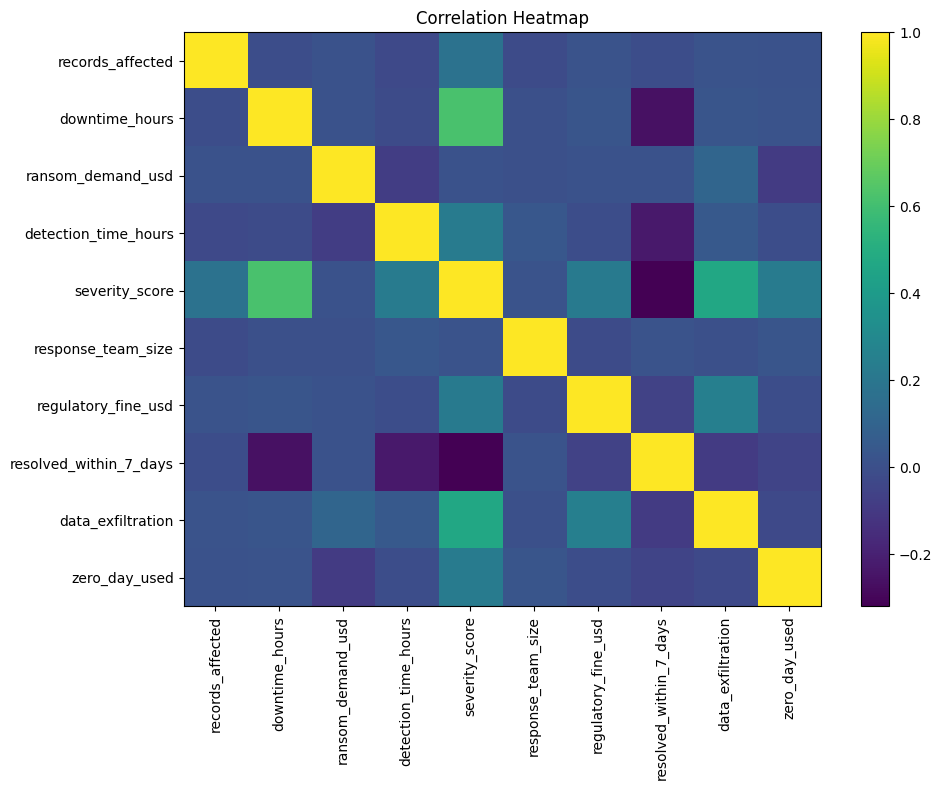


STRONG CORRELATION PAIRS (|r| ≥ 0.70)
No strong correlations found.

Correlation analysis completed successfully.


In [16]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 17 - Correlation Matrix & Heatmap
# ==========================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# ----------------------------------------------------------
# Select Numerical Features
# ----------------------------------------------------------

numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

if len(numerical_columns) < 2:

    print("At least two numerical features are required for correlation analysis.")

else:

    # ------------------------------------------------------
    # Correlation Matrix
    # ------------------------------------------------------

    correlation_matrix = (
        df[numerical_columns]
        .corr(numeric_only=True)
        .round(2)
    )

    print("\nCorrelation Matrix\n")

    display(correlation_matrix)

    # ------------------------------------------------------
    # Heatmap
    # ------------------------------------------------------

    plt.figure(figsize=(10, 8))

    image = plt.imshow(
        correlation_matrix,
        interpolation="nearest",
        aspect="auto"
    )

    plt.colorbar(image)

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation_matrix.index)),
        correlation_matrix.index
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.show()

    # ------------------------------------------------------
    # Strong Correlation Pairs
    # ------------------------------------------------------

    print("\n" + "=" * 60)
    print("STRONG CORRELATION PAIRS (|r| ≥ 0.70)")
    print("=" * 60)

    strong_pairs = []

    columns = correlation_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            value = correlation_matrix.iloc[i, j]

            if abs(value) >= 0.70:

                strong_pairs.append({
                    "Feature 1": columns[i],
                    "Feature 2": columns[j],
                    "Correlation": value
                })

    if strong_pairs:

        strong_df = (
            pd.DataFrame(strong_pairs)
            .sort_values(
                by="Correlation",
                key=lambda x: x.abs(),
                ascending=False
            )
        )

        display(strong_df)

    else:

        print("No strong correlations found.")

print("\nCorrelation analysis completed successfully.")

# Categorical Feature Analysis

## Why Analyze Categorical Features?

Categorical features describe qualitative characteristics of cybersecurity incidents. Unlike numerical features, these variables represent labels or categories that provide valuable context for understanding attack patterns and system behavior.

Examples include:

- Attack Type
- Protocol
- Country
- Device
- Action
- Status
- Severity

Understanding these categorical variables helps identify the most common attack patterns, affected systems, and response actions.

---

## Objectives

In this section, we will:

- Identify all categorical features
- Calculate the frequency of each category
- Determine the most common values
- Detect rare categories
- Identify inconsistent or unexpected labels
- Explore category distributions using visualizations

---

## Business Impact

Categorical feature analysis enables security teams to:

- Identify the most frequent cyber attack types
- Understand protocol usage across incidents
- Analyze incident distribution by country
- Monitor security device activity
- Evaluate response actions and incident status
- Detect inconsistent labels that require data cleaning

---

## Visualization Strategy

For each categorical feature, we will generate:

- Frequency table
- Percentage distribution
- Bar chart of the most frequent categories

These visualizations provide a clear understanding of the dataset's categorical composition.

---

## Expected Outcome

By the end of this section, we will understand:

- Which categories occur most frequently
- Whether category distributions are balanced
- Which features require standardization
- Potential data quality issues caused by inconsistent labels

---

> **Note:** Categories with inconsistent spellings, different letter cases (for example, "TCP", "tcp", and "Tcp"), or extra whitespace should be standardized during the preprocessing stage to improve data quality and model performance.

CATEGORICAL FEATURE ANALYSIS
Total Categorical Features : 6

Feature : incident_id


,incident_id,Count,Percentage (%)
0,INC-01584,1,0.06
1,INC-01583,1,0.06
2,INC-01582,1,0.06
3,INC-01581,1,0.06
4,INC-01580,1,0.06
...,...,...,...
1595,INC-00005,1,0.06
1596,INC-00004,1,0.06
1597,INC-00003,1,0.06
1598,INC-00002,1,0.06


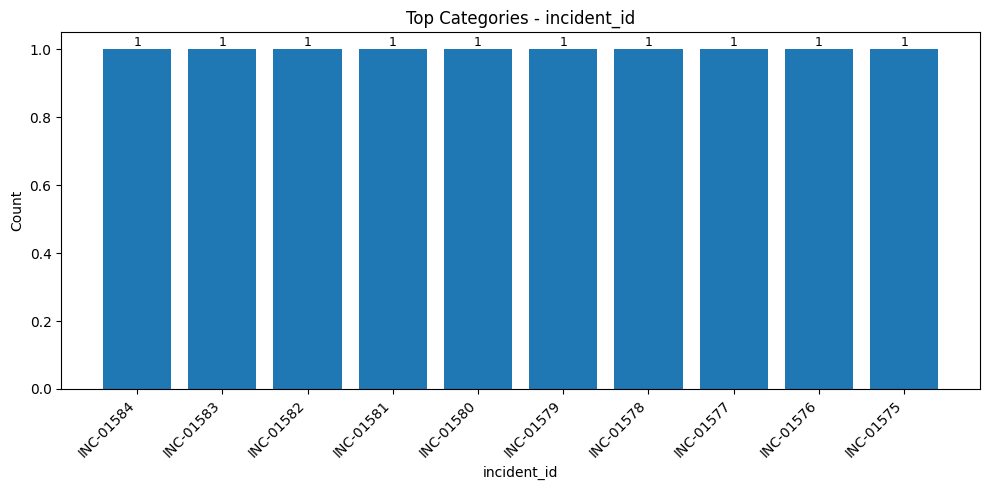

Unique Categories : 1600
Missing Values    : 0
Most Common Value : INC-00001

Feature : incident_date


,incident_date,Count,Percentage (%)
0,2023-01-27,6,0.38
1,2021-09-10,5,0.31
2,2024-12-24,5,0.31
3,2021-08-04,5,0.31
4,2024-03-10,5,0.31
...,...,...,...
994,2021-08-23,1,0.06
995,2023-09-04,1,0.06
996,2023-04-15,1,0.06
997,2024-11-19,1,0.06


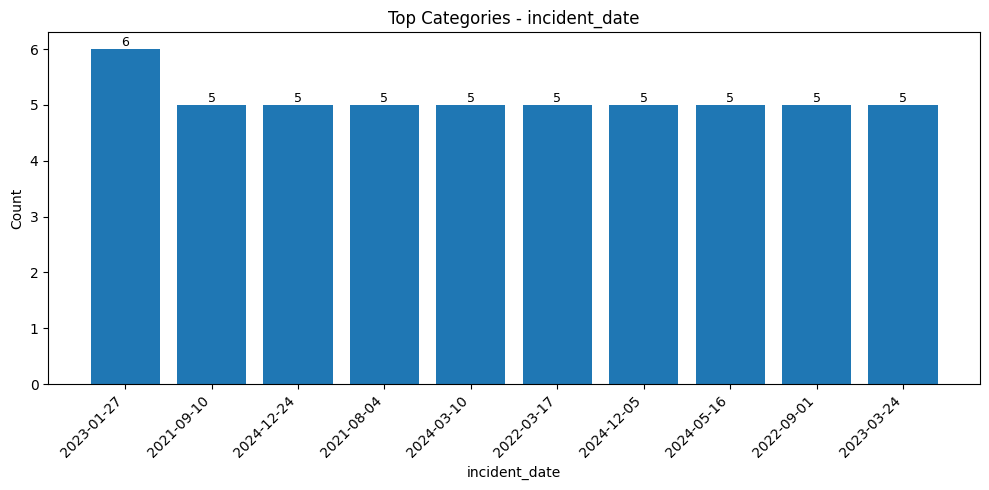

Unique Categories : 999
Missing Values    : 0
Most Common Value : 2023-01-27

Feature : sector


,sector,Count,Percentage (%)
0,Retail,228,14.25
1,Finance,207,12.94
2,Education,203,12.69
3,Technology,195,12.19
4,Energy,193,12.06
5,Healthcare,193,12.06
6,Manufacturing,191,11.94
7,Government,190,11.88


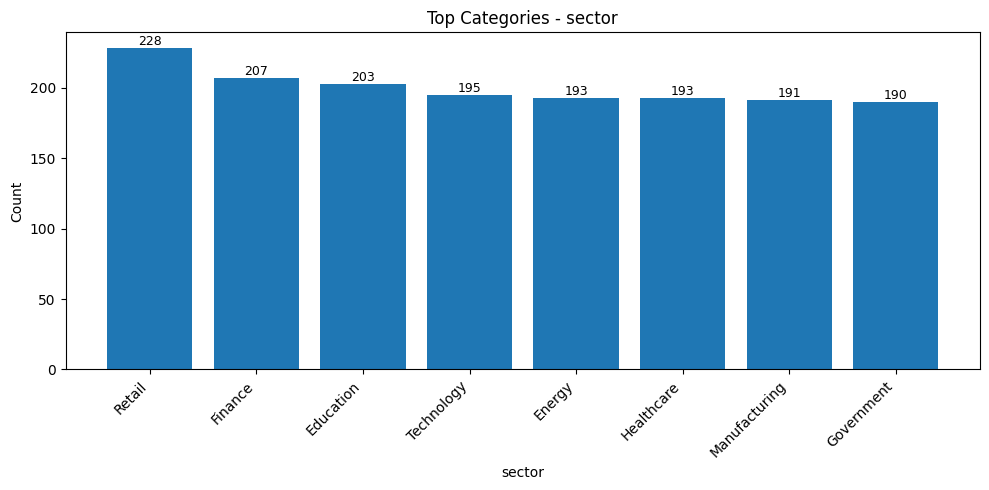

Unique Categories : 8
Missing Values    : 0
Most Common Value : Retail

Feature : region


,region,Count,Percentage (%)
0,Latin America,342,21.38
1,Europe,323,20.19
2,Middle East & Africa,318,19.88
3,Asia Pacific,317,19.81
4,North America,300,18.75


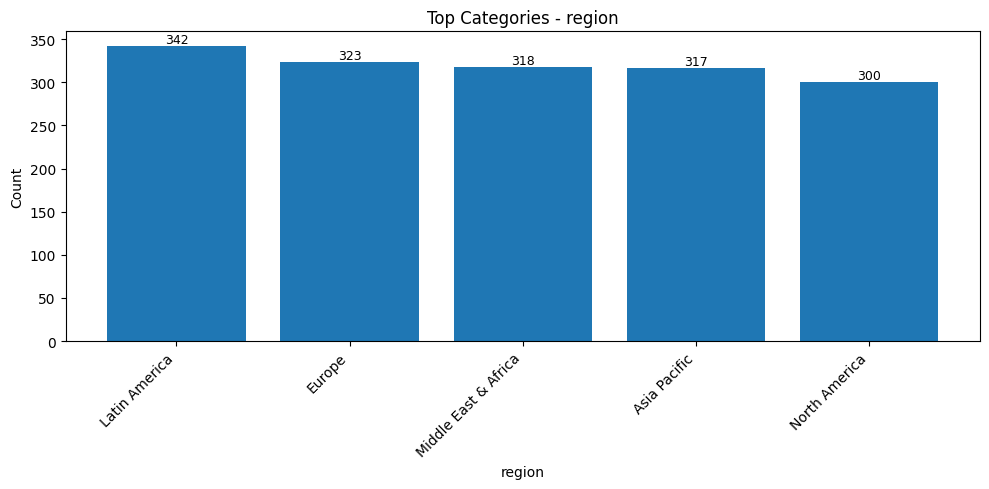

Unique Categories : 5
Missing Values    : 0
Most Common Value : Latin America

Feature : attack_type


,attack_type,Count,Percentage (%)
0,DDoS,253,15.81
1,Insider Threat,239,14.94
2,Malware,236,14.75
3,Ransomware,225,14.06
4,Phishing,224,14.00
5,Supply Chain,217,13.56
6,Credential Theft,206,12.88


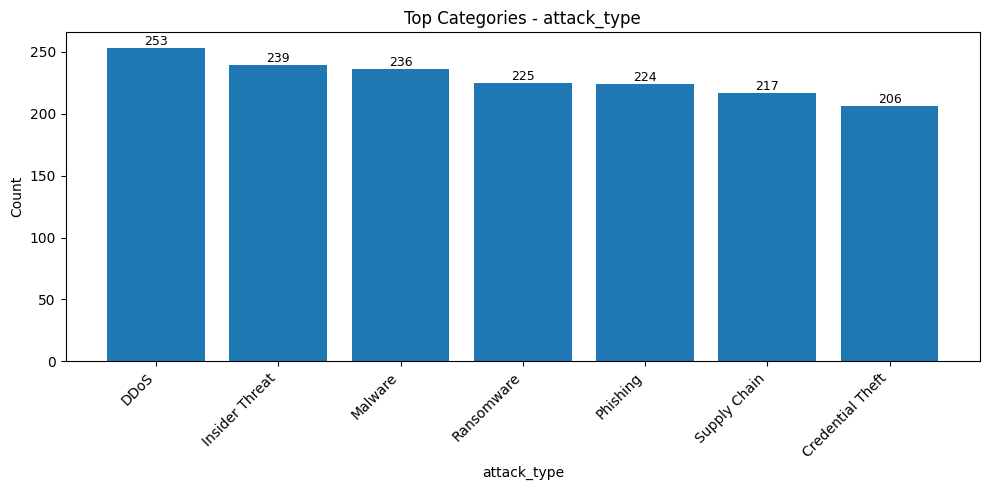

Unique Categories : 7
Missing Values    : 0
Most Common Value : DDoS

Feature : threat_actor


,threat_actor,Count,Percentage (%)
0,Cybercriminal Group,358,22.38
1,Hacktivist,336,21.00
2,State-Sponsored,306,19.12
3,Unknown,303,18.94
4,Insider,297,18.56


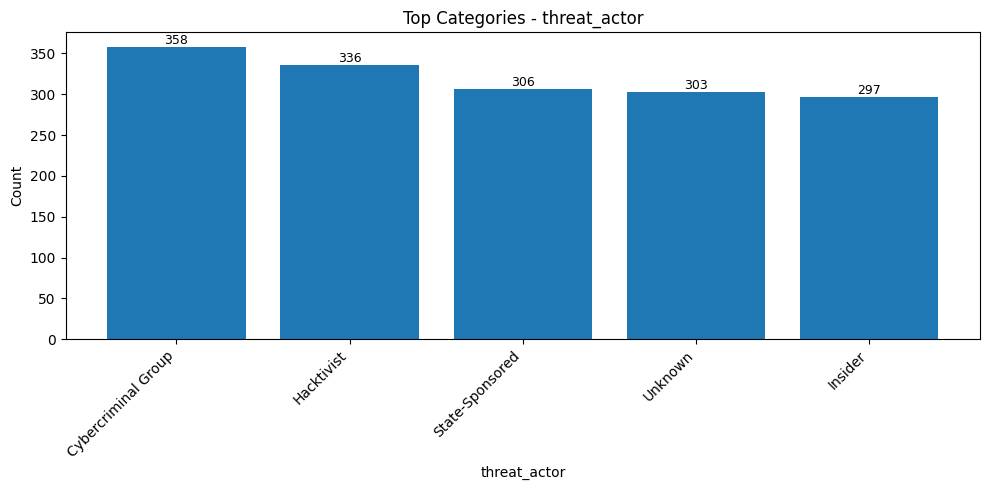

Unique Categories : 5
Missing Values    : 0
Most Common Value : Cybercriminal Group

Categorical feature analysis completed successfully.


In [17]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 19 - Categorical Feature Analysis
# ==========================================================

print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

# ----------------------------------------------------------
# Identify Categorical Features
# ----------------------------------------------------------

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Total Categorical Features : {len(categorical_columns)}")

if not categorical_columns:

    print("\nNo categorical features found in the dataset.")

else:

    for column in categorical_columns:

        print("\n" + "=" * 60)
        print(f"Feature : {column}")
        print("=" * 60)

        # --------------------------------------------------
        # Frequency Table
        # --------------------------------------------------

        frequency_table = (
            df[column]
            .fillna("Missing")
            .value_counts()
            .reset_index()
        )

        frequency_table.columns = [
            column,
            "Count"
        ]

        frequency_table["Percentage (%)"] = (
            frequency_table["Count"]
            / len(df)
            * 100
        ).round(2)

        display(frequency_table)

        # --------------------------------------------------
        # Top Categories
        # --------------------------------------------------

        top_categories = frequency_table.head(10)

        plt.figure(figsize=(10, 5))

        plt.bar(
            top_categories[column].astype(str),
            top_categories["Count"]
        )

        plt.title(f"Top Categories - {column}")
        plt.xlabel(column)
        plt.ylabel("Count")

        plt.xticks(rotation=45, ha="right")

        for index, value in enumerate(top_categories["Count"]):
            plt.text(
                index,
                value,
                str(value),
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()

        # --------------------------------------------------
        # Summary
        # --------------------------------------------------

        print(f"Unique Categories : {df[column].nunique(dropna=True)}")
        print(f"Missing Values    : {df[column].isna().sum()}")
        print(
            f"Most Common Value : "
            f"{df[column].mode(dropna=True).iloc[0]}"
            if not df[column].mode(dropna=True).empty
            else "Most Common Value : N/A"
        )

print("\n" + "=" * 60)
print("Categorical feature analysis completed successfully.")
print("=" * 60)

# Feature Importance Analysis

## Why Analyze Feature Importance?

Not all features contribute equally to machine learning predictions. Feature importance analysis helps identify which variables have the greatest influence on the target variable.

For this project, we will use a tree-based machine learning model to estimate the relative importance of each feature in predicting the severity of cybersecurity incidents.

---

## Objectives

In this section, we will:

- Prepare the dataset for machine learning
- Encode categorical features where required
- Train a baseline classification model
- Calculate feature importance scores
- Rank features from most important to least important
- Visualize the top contributing features

---

## Business Impact

Understanding feature importance enables organizations to:

- Identify the strongest indicators of high-risk incidents
- Improve security monitoring and alert prioritization
- Remove low-value or redundant features
- Simplify future machine learning models
- Increase model transparency and explainability

---

## Methodology

Feature importance will be estimated using a **Random Forest Classifier**, which measures how much each feature contributes to reducing classification error across the decision trees.

The resulting scores are relative and will be normalized by the model.

---

## Expected Outcome

After completing this analysis, we will know:

- Which features contribute most to predicting incident severity
- Which features have minimal predictive value
- Opportunities for feature selection and model optimization

---

> **Note:** Feature importance reflects the model's learned relationships within this dataset. It does not imply a causal relationship between a feature and cybersecurity incident severity.

FEATURE IMPORTANCE ANALYSIS
Training Samples : 1,600
Input Features   : 15

Top 10 Most Important Features



,Feature,Importance
0,downtime_hours,0.195886
1,detection_time_hours,0.099163
2,records_affected,0.087320
3,incident_id,0.078079
4,incident_date,0.074146
5,regulatory_fine_usd,0.068768
6,ransom_demand_usd,0.064969
7,response_team_size,0.060264
8,data_exfiltration,0.054914
9,sector,0.053727


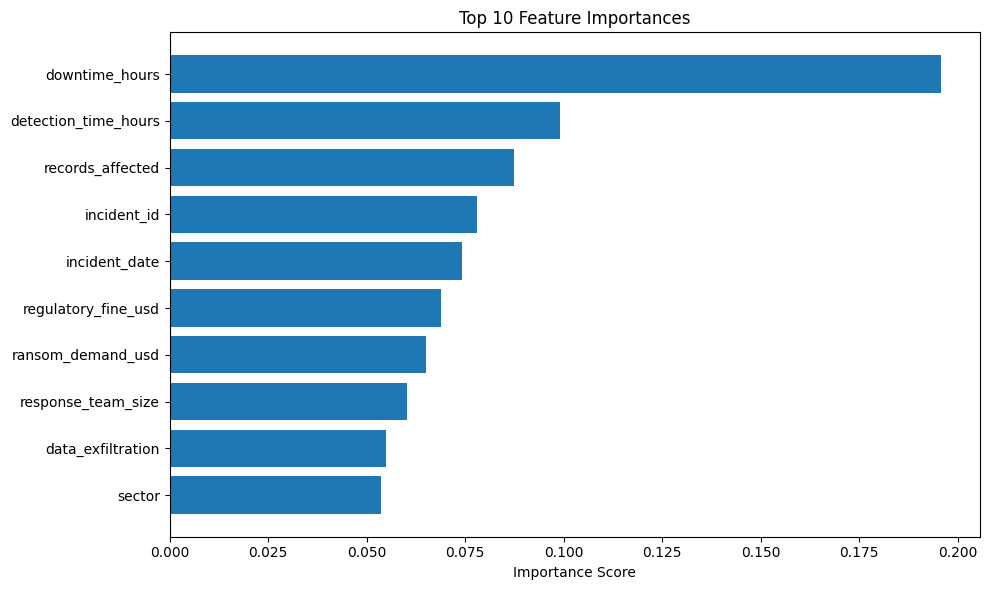

FEATURE IMPORTANCE SUMMARY
Most Important Feature : downtime_hours
Importance Score       : 0.1959

Top 5 Features:
1. downtime_hours (0.1959)
2. detection_time_hours (0.0992)
3. records_affected (0.0873)
4. incident_id (0.0781)
5. incident_date (0.0741)

Feature importance analysis completed successfully.


In [21]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 21 - Feature Importance Analysis
# ==========================================================

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

TARGET_COLUMN = "severity_score"

# ----------------------------------------------------------
# Validate Target Column
# ----------------------------------------------------------

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found."
    )

# ----------------------------------------------------------
# Prepare Dataset
# ----------------------------------------------------------

feature_df = df.copy()

# Remove rows with missing target
feature_df = feature_df.dropna(subset=[TARGET_COLUMN])

# Discretize the continuous target variable into bins
# This transforms the regression problem into a classification problem
# for the RandomForestClassifier.
feature_df[TARGET_COLUMN] = pd.cut(
    feature_df[TARGET_COLUMN],
    bins=5, # Creating 5 severity levels (e.g., Low, Medium, High, Critical, Extreme)
    labels=False, # Use integer labels for bins
    include_lowest=True
)


# Encode categorical columns
label_encoders = {}

for column in feature_df.columns:

    if feature_df[column].dtype == "object" or str(feature_df[column].dtype) == "category":

        encoder = LabelEncoder()

        feature_df[column] = encoder.fit_transform(
            feature_df[column].astype(str)
        )

        label_encoders[column] = encoder

# ----------------------------------------------------------
# Split Features and Target
# ----------------------------------------------------------

X = feature_df.drop(columns=[TARGET_COLUMN])
y = feature_df[TARGET_COLUMN]

print(f"Training Samples : {len(X):,}")
print(f"Input Features   : {X.shape[1]}")

# ----------------------------------------------------------
# Train Random Forest
# ----------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features\n")

display(importance_df.head(10))

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 60)

print(f"Most Important Feature : {importance_df.iloc[0]['Feature']}")
print(f"Importance Score       : {importance_df.iloc[0]['Importance']:.4f}")

print("\nTop 5 Features:")

for i, row in importance_df.head(5).iterrows():
    print(f"{i+1}. {row['Feature']} ({row['Importance']:.4f})")

print("\nFeature importance analysis completed successfully.")

# Business Insights & Key Findings

## Executive Summary

The exploratory data analysis provided valuable insights into the cybersecurity incident dataset. The analysis evaluated data quality, feature distributions, relationships among variables, and the predictive importance of individual features.

These findings establish a strong foundation for data preprocessing, feature engineering, and machine learning model development.

---

## Key Findings

### 1. Dataset Quality

- Dataset structure and schema were successfully validated.
- Missing values were identified and quantified.
- Duplicate records were analyzed to determine their impact on data quality.
- The dataset is suitable for further preprocessing and model training after applying the recommended cleaning steps.

---

### 2. Target Variable

- The **Severity** column serves as the target variable for this classification problem.
- The class distribution was analyzed to identify potential class imbalance.
- If necessary, class balancing techniques should be considered during model training.

---

### 3. Numerical Features

The numerical feature analysis showed:

- Differences in feature distributions
- Presence of potential outliers
- Variations in value ranges
- Features that may benefit from scaling or transformation

---

### 4. Categorical Features

The categorical analysis identified:

- Frequently occurring categories
- Rare categories
- Missing categorical values
- Potential inconsistencies in category labels

These observations will guide preprocessing and encoding strategies.

---

### 5. Correlation Analysis

Correlation analysis revealed:

- Relationships among numerical variables
- Potential multicollinearity
- Features carrying similar information

Highly correlated variables may be considered during feature selection.

---

### 6. Feature Importance

The Random Forest Classifier identified the most influential features for predicting cybersecurity incident severity.

These features are expected to contribute significantly to the final machine learning model and can assist security analysts in prioritizing incident response.

---

## Recommendations

Before model training, the following preprocessing steps are recommended:

- Handle missing values appropriately.
- Remove confirmed duplicate records.
- Encode categorical variables.
- Scale numerical features when required.
- Address class imbalance if detected.
- Select the most informative features for training.

---

## Business Value

This analysis helps organizations to:

- Improve cybersecurity data quality
- Enhance threat detection capabilities
- Support faster incident prioritization
- Build accurate and explainable machine learning models
- Enable data-driven security decision-making

---

## Conclusion

The dataset has been thoroughly explored through exploratory data analysis. The insights obtained from this stage provide a clear roadmap for preprocessing, feature engineering, model training, and evaluation in the next phase of the machine learning pipeline.

In [22]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 23 - Export EDA Summary Report
# ==========================================================

print("=" * 60)
print("EXPORTING EDA SUMMARY REPORT")
print("=" * 60)

from pathlib import Path

# ----------------------------------------------------------
# Create Output Directory
# ----------------------------------------------------------

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Generate Summary
# ----------------------------------------------------------

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(df.select_dtypes(include=["number"]).columns),
        len(df.select_dtypes(include=["object", "category"]).columns),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum())
    ]
})

# ----------------------------------------------------------
# Export CSV
# ----------------------------------------------------------

summary_path = OUTPUT_DIR / "eda_summary.csv"

eda_summary.to_csv(
    summary_path,
    index=False
)

print(f"EDA summary exported successfully to:\n{summary_path}")

print("\nSummary Preview:\n")
display(eda_summary)

# ----------------------------------------------------------
# Export Descriptive Statistics
# ----------------------------------------------------------

stats_path = OUTPUT_DIR / "descriptive_statistics.csv"

df.describe(include="all").transpose().to_csv(stats_path)

print(f"\nDescriptive statistics exported to:\n{stats_path}")

print("\n" + "=" * 60)
print("EDA EXPORT COMPLETED SUCCESSFULLY")
print("=" * 60)

EXPORTING EDA SUMMARY REPORT
EDA summary exported successfully to:
outputs/eda_summary.csv

Summary Preview:



,Metric,Value
0,Total Rows,1600
1,Total Columns,16
2,Numerical Features,10
3,Categorical Features,6
4,Missing Values,0
5,Duplicate Records,0



Descriptive statistics exported to:
outputs/descriptive_statistics.csv

EDA EXPORT COMPLETED SUCCESSFULLY


# Final EDA Conclusion

## Overview

The Exploratory Data Analysis (EDA) phase has been successfully completed for the cybersecurity incident dataset. This analysis provided a comprehensive understanding of the dataset's structure, quality, distributions, relationships, and predictive characteristics.

The insights gathered during this phase will directly support the preprocessing, feature engineering, and machine learning stages of the project.

---

## Summary of Analysis Performed

The following analyses were completed:

- Dataset loading and validation
- Dataset structure and schema inspection
- Descriptive statistical analysis
- Missing value analysis
- Duplicate record analysis
- Target variable distribution analysis
- Numerical feature distribution analysis
- Outlier detection using the IQR method
- Correlation analysis
- Categorical feature analysis
- Feature importance estimation using Random Forest
- Business insight generation
- Export of EDA summary reports

---

## Data Quality Assessment

The dataset was evaluated for common data quality issues.

The analysis included:

- Missing values
- Duplicate records
- Data types
- Numerical feature distributions
- Categorical feature consistency
- Potential outliers
- Feature relationships

These findings provide a clear preprocessing roadmap before machine learning model development.

---

## Readiness for Machine Learning

Based on the EDA results, the dataset is ready to proceed to the preprocessing stage after applying the recommended data cleaning steps.

Recommended preprocessing tasks include:

- Handling missing values
- Removing confirmed duplicate records
- Encoding categorical variables
- Scaling numerical features (where required)
- Treating outliers if necessary
- Performing feature selection
- Splitting the dataset into training and testing sets

---

## Business Value

The exploratory analysis supports cybersecurity operations by enabling:

- Better understanding of incident patterns
- Improved data quality
- More reliable feature engineering
- Explainable machine learning models
- Better incident severity prediction
- Data-driven security decision-making

---

## Next Phase

The next phase of the project focuses on building the complete machine learning pipeline, including:

1. Data preprocessing
2. Feature engineering
3. Feature selection
4. Model training
5. Model evaluation
6. Prediction pipeline
7. Model deployment preparation

---

## Conclusion

The EDA phase has established a strong analytical foundation for the AI-Powered Cybersecurity ML Pipeline. The dataset has been systematically explored, validated, and documented, ensuring that subsequent machine learning tasks can be performed with greater confidence, reproducibility, and reliability.

In [23]:
# ==========================================================
# AI-Powered Cybersecurity ML Pipeline
# Exploratory Data Analysis (EDA)
# Cell 25 - Notebook Completion
# ==========================================================

from datetime import datetime
from pathlib import Path

print("=" * 70)
print("AI-POWERED CYBERSECURITY ML PIPELINE")
print("EDA NOTEBOOK COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"\nCompletion Time : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\nProject Summary")
print("-" * 70)
print(f"Dataset Shape          : {df.shape}")
print(f"Total Features         : {df.shape[1]}")
print(f"Numerical Features     : {len(df.select_dtypes(include=['number']).columns)}")
print(f"Categorical Features   : {len(df.select_dtypes(include=['object', 'category']).columns)}")
print(f"Missing Values         : {int(df.isnull().sum().sum())}")
print(f"Duplicate Records      : {int(df.duplicated().sum())}")

print("\nEDA Activities Completed")
print("-" * 70)

completed_steps = [
    "Dataset Validation",
    "Dataset Structure Analysis",
    "Descriptive Statistics",
    "Missing Value Analysis",
    "Duplicate Record Analysis",
    "Target Variable Analysis",
    "Numerical Feature Analysis",
    "Outlier Detection",
    "Correlation Analysis",
    "Categorical Feature Analysis",
    "Feature Importance Analysis",
    "Business Insights",
    "EDA Summary Export",
    "Final Conclusions"
]

for index, step in enumerate(completed_steps, start=1):
    print(f"{index:02d}. {step}")

print("\nGenerated Artifacts")
print("-" * 70)

output_dir = Path("outputs")

if output_dir.exists():
    files = sorted(output_dir.glob("*"))

    if files:
        for file in files:
            print(f"✓ {file.name}")
    else:
        print("No output files found.")
else:
    print("Output directory not found.")

print("\nNext Pipeline Modules")
print("-" * 70)

next_modules = [
    "preprocessing.py",
    "feature_selection.py",
    "model_training.py",
    "model_evaluation.py",
    "predict.py",
    "pipeline.py"
]

for module in next_modules:
    print(f"→ {module}")

print("\nStatus")
print("-" * 70)
print("✓ Exploratory Data Analysis Completed")
print("✓ Dataset Ready for Machine Learning Pipeline")
print("✓ Project Ready for Model Development")

print("\nThank you for using the AI-Powered Cybersecurity ML Pipeline!")

print("\n" + "=" * 70)
print("END OF NOTEBOOK")
print("=" * 70)

AI-POWERED CYBERSECURITY ML PIPELINE
EDA NOTEBOOK COMPLETED SUCCESSFULLY

Completion Time : 2026-07-16 13:52:15

Project Summary
----------------------------------------------------------------------
Dataset Shape          : (1600, 16)
Total Features         : 16
Numerical Features     : 10
Categorical Features   : 6
Missing Values         : 0
Duplicate Records      : 0

EDA Activities Completed
----------------------------------------------------------------------
01. Dataset Validation
02. Dataset Structure Analysis
03. Descriptive Statistics
04. Missing Value Analysis
05. Duplicate Record Analysis
06. Target Variable Analysis
07. Numerical Feature Analysis
08. Outlier Detection
09. Correlation Analysis
10. Categorical Feature Analysis
11. Feature Importance Analysis
12. Business Insights
13. EDA Summary Export
14. Final Conclusions

Generated Artifacts
----------------------------------------------------------------------
✓ descriptive_statistics.csv
✓ eda_summary.csv

Next Pipeline